In [1]:
import numpy as np
import os, tqdm
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import corner

In [2]:
output_stat_dir = '../output'

In [53]:
# Astro params
params = ['ION_Tvir_MIN','R_BUBBLE_MAX','HII_EFF_FACTOR']
# Fisher_Param = ['$T_{Vir}$','$R_{Max}$','$\zeta$']
Fisher_Param = [r'$T_{Vir}~[10^4 \mathrm{K}]$', r'$R_{Max}$', r'$\zeta$']
nparams = len(params)
# parameter values for fiducial simulation
fid = np.array([10**4.7,15,30])

In [54]:
model_files = {}

model_files['PS 1D'] = {
    'AA* (100 h)' : os.path.join(output_stat_dir, f'posterior_covariance_matrix_AAstar_100hours_ps.txt'),
    'AA* (1000 h)': os.path.join(output_stat_dir, f'posterior_covariance_matrix_AAstar_1000hours_ps.txt'),
    'AA4 (1000 h)': os.path.join(output_stat_dir, f'posterior_covariance_matrix_AA4_1000hours_ps.txt'),
}

model_files['PS 2D'] = {
    'AA* (100 h)' : os.path.join(output_stat_dir, f'posterior_covariance_matrix_AAstar_100hours_PS2D_no_wedge_updated.txt'),
    'AA* (1000 h)': os.path.join(output_stat_dir, f'posterior_covariance_matrix_AAstar_1000hours_PS2D_no_wedge_updated.txt'),
    'AA4 (1000 h)': os.path.join(output_stat_dir, f'posterior_covariance_matrix_AA4_1000hours_PS2D_no_wedge_updated.txt'),
}

model_files['MAPS'] = {
    'AA* (100 h)' : os.path.join(output_stat_dir, f'posterior_covariance_matrix_AAstar_100hours_MAPS.txt'),
    'AA* (1000 h)': os.path.join(output_stat_dir, f'posterior_covariance_matrix_AAstar_1000hours_MAPS.txt'),
    'AA4 (1000 h)': os.path.join(output_stat_dir, f'posterior_covariance_matrix_AA4_1000hours_MAPS.txt'),
}

In [55]:
# --- Styling Definitions ---
# Define colors for each model type and linestyles for each case
style_guide = {
    'PS 1D': {'color': 'C0', 'label': 'Spherical PS'},
    'PS 2D': {'color': 'C1', 'label': 'Cylindrical PS'},
    'MAPS' : {'color': 'C2', 'label': 'Multi-frequency Angular PS'},
}

linestyles = {
    'AA* (100 h)' : ('-', 'AA* (100 h)'),
    'AA* (1000 h)': ('--', 'AA* (1000 h)'),
    'AA4 (1000 h)': (':', 'AA4 (1000 h)')
}

--- PS 1D ---
AA* (100 h): [  2.60646504 -77.16475325  12.6444227 ], [  7.57642945 109.65361155  48.80356222]
AA* (1000 h): [  3.83623757 -27.4172875   25.27010243], [ 6.07120071 52.33007369 34.44176451]
AA4 (1000 h): [ 4.54345518 -0.75574874 28.16075682], [ 5.45150513 29.30757918 31.88246309]


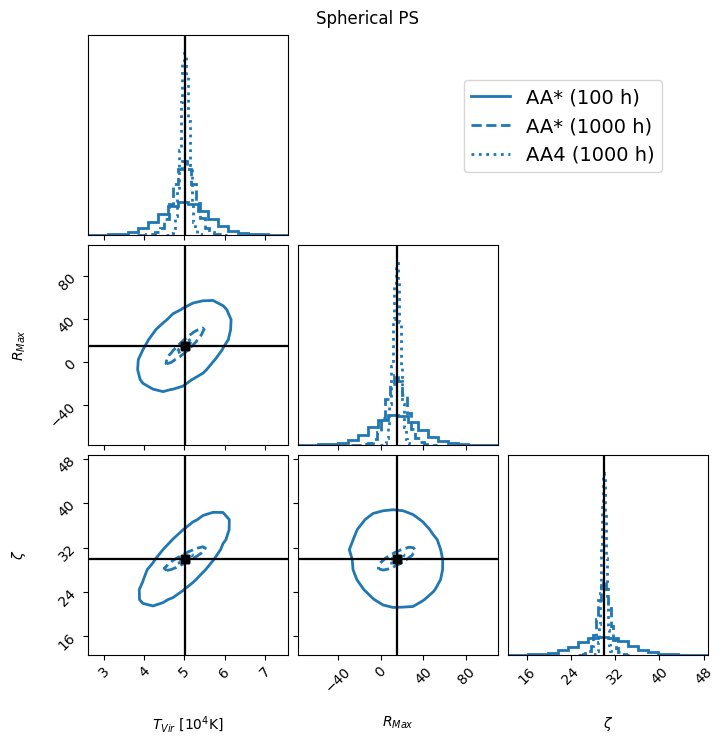

--- PS 2D ---
AA* (100 h): [ -21.86449527 -138.0976079   -72.44114976], [ 29.96958038 163.7254568  126.7837037 ]
AA* (1000 h): [-6.88614387e-01 -5.88044652e+01 -4.44978497e-02], [10.91770243 84.03396802 60.15225598]
AA4 (1000 h): [ -0.36480744 -57.81940053   2.47433211], [ 9.83532569 80.71828301 57.04344374]


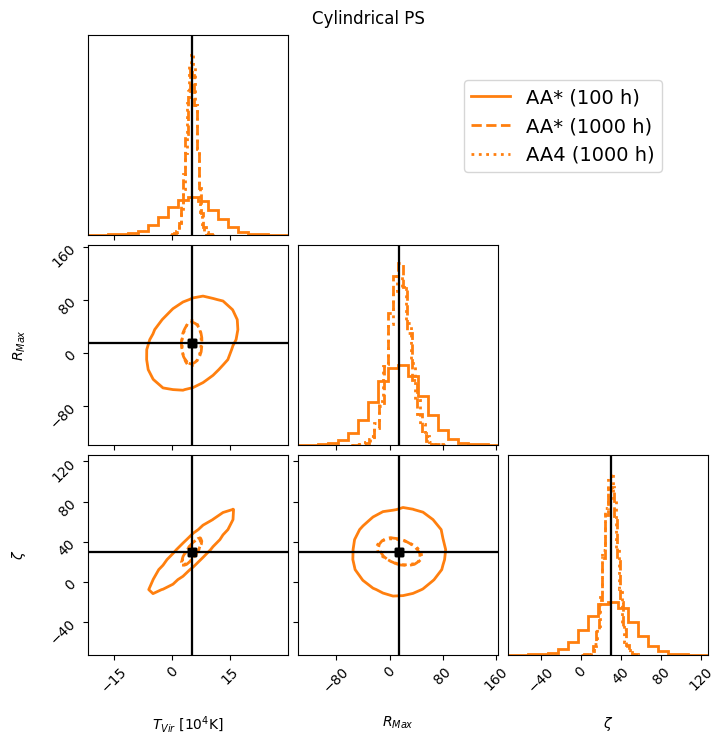

--- MAPS ---
AA* (100 h): [ 3.76385902  1.71572853 24.74253911], [ 6.2272513  27.79164485 35.32802453]
AA* (1000 h): [ 4.66434811 11.73244592 28.55070582], [ 5.37544162 18.35565087 31.42614419]
AA4 (1000 h): [ 4.72168331 11.86796114 28.68252218], [ 5.36582709 18.11818424 31.32030638]


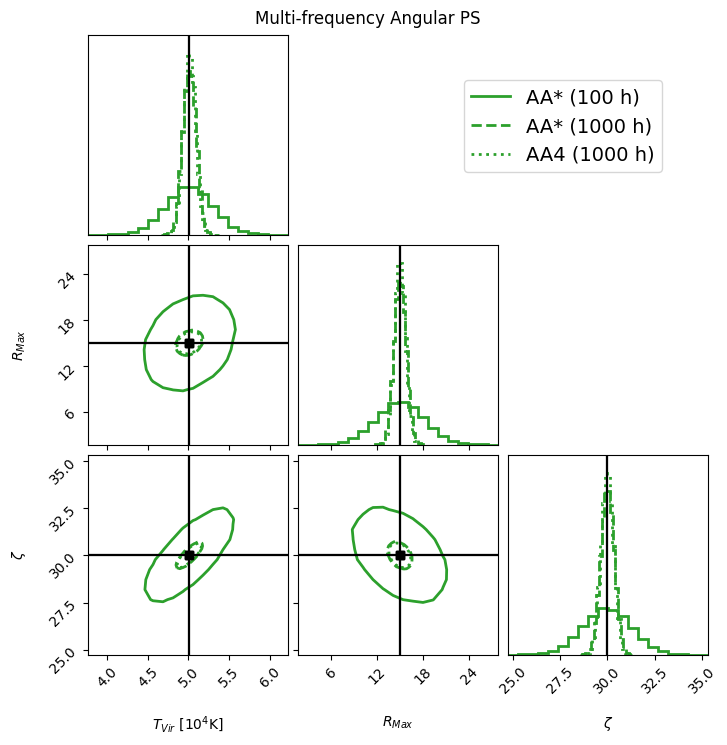

In [57]:
# --- Plotting ---
n_samples = 100000

truths = fid.copy()
truths[0] /= 1e4

levels = (0.864,) #(2-sigma, )
# levels = (0.675, 0.864) #(1-sigma, 2-sigma)

plot_cases = ['AA* (100 h)', 'AA* (1000 h)', 'AA4 (1000 h)']
# plot_cases = ['AA* (1000 h)', 'AA4 (1000 h)']

ranges = None

for model_type, cases in model_files.items():
    fig = None
    color = style_guide[model_type]['color']
    # Loop through the different observation cases
    print(f"--- {model_type} ---")
    for case_name, file_path in cases.items():
        if case_name in plot_cases:
            linestyle = linestyles[case_name][0]
            
            # Load covariance and generate samples
            cov = np.loadtxt(file_path)
            fisher_samples = np.random.multivariate_normal(fid, cov, size=n_samples)
            fisher_samples[:,0] /= 1e4
            print(f"{case_name}: {fisher_samples.min(axis=0)}, {fisher_samples.max(axis=0)}")
            
            # Add samples to the corner plot with specified styles
            fig = corner.corner(
                fisher_samples,
                fig=fig,
                labels=Fisher_Param,
                plot_datapoints=False,
                plot_density=False,
                levels=levels,
                truths=truths,
                truth_color='black',
                color=color, # Base color for the group
                # Apply linestyles to both 1D histograms and 2D contours
                hist_kwargs={'linestyle': linestyle, 'lw': 2, 'density': True},
                contour_kwargs={'linestyles': linestyle, 'linewidths': 2},
                range=ranges,
            )

    # --- Create Custom Legend ---
    # Create proxy artists for the legend
    legend_elements = []

    fig.suptitle(f"{style_guide[model_type]['label']}")
        
    # Add entries for observation cases (linestyles)
    for case_name, (ls, label) in linestyles.items():
        if case_name in plot_cases:
            legend_elements.append(mlines.Line2D(
                [], [], color=color, lw=2, linestyle=ls, label=label
            ))

    # Add the legend to the top-right corner of the figure
    fig.legend(handles=legend_elements, loc='upper right', fontsize=14, bbox_to_anchor=(0.90, 0.90))

    plt.show()

--- PS 1D ---
AA* (100 h): [  2.17220474 -66.73892663  11.22670626], [  7.47696095 109.95854603  49.61355988]
AA* (1000 h): [  3.95330579 -25.29795724  25.64789184], [ 6.19350163 55.52817115 34.68628996]
AA4 (1000 h): [ 4.60578883  0.52833161 28.27097918], [ 5.41673736 28.06032353 31.73627866]


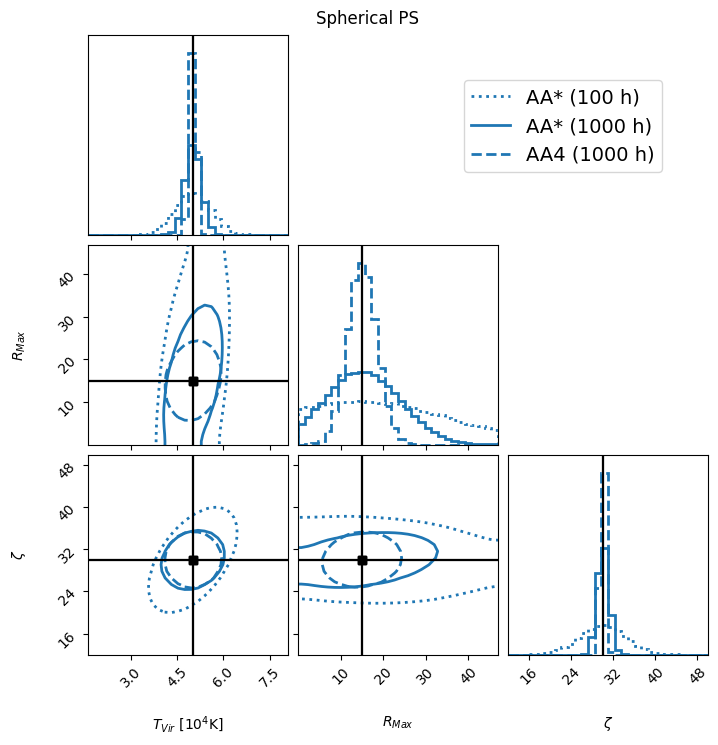

--- PS 1D ---
AA* (1000 h): [  3.93693875 -22.19970507  25.29704827], [ 6.12271492 54.25640504 35.05806184]
--- PS 2D ---
AA* (1000 h): [ -1.01947071 -56.74167448  -5.54995587], [10.75357072 92.35931567 60.48628494]
--- MAPS ---
AA* (1000 h): [ 4.63280594 11.459884   28.49530189], [ 5.38024052 18.64490455 31.72077916]


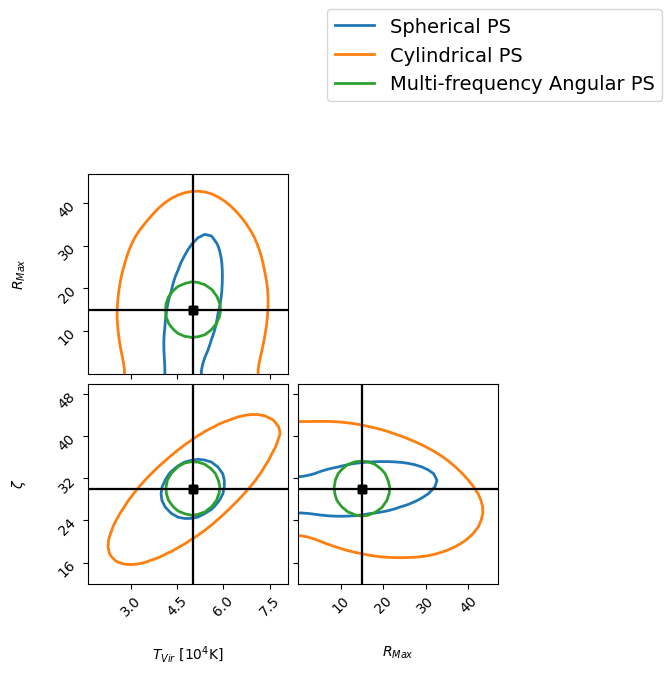

In [ ]:
# --- Styling Definitions ---
# Define colors for each model type and linestyles for each case
style_guide = {
    'PS 1D': {'color': 'C0', 'label': 'Spherical PS'},
    'PS 2D': {'color': 'C1', 'label': 'Cylindrical PS'},
    'MAPS' : {'color': 'C2', 'label': 'Multi-frequency Angular PS'},
}

linestyles = {
    'AA* (100 h)' : (':', 'AA* (100 h)'),
    'AA* (1000 h)': ('-', 'AA* (1000 h)'),
    'AA4 (1000 h)': ('--', 'AA4 (1000 h)')
}

# --- Plotting ---
n_samples = 100000
remove_hist1d = True

truths = fid.copy()
truths[0] /= 1e4

levels = (0.864,) #(2-sigma, )
# levels = (0.675, 0.864) #(1-sigma, 2-sigma)

bins = 30
smooth = 2.0
smooth1d = None #2.0
ranges = [(1.6,8.1),(0,47),(12,50)]

plot_model = ['PS 1D']
plot_cases = ['AA* (100 h)', 'AA* (1000 h)', 'AA4 (1000 h)']

for model_type, cases in model_files.items():
    if model_type not in plot_model:
        continue
    fig = None
    color = style_guide[model_type]['color']
    # Loop through the different observation cases
    print(f"--- {model_type} ---")
    for case_name, file_path in cases.items():
        if case_name in plot_cases:
            linestyle = linestyles[case_name][0]
            
            # Load covariance and generate samples
            cov = np.loadtxt(file_path)
            fisher_samples = np.random.multivariate_normal(fid, cov, size=n_samples)
            fisher_samples[:,0] /= 1e4
            print(f"{case_name}: {fisher_samples.min(axis=0)}, {fisher_samples.max(axis=0)}")
            
            # Add samples to the corner plot with specified styles
            fig = corner.corner(
                fisher_samples,
                bins=bins,
                fig=fig,
                labels=Fisher_Param,
                plot_datapoints=False,
                plot_density=False,
                levels=levels,
                truths=truths,
                truth_color='black',
                color=color, # Base color for the group
                # Apply linestyles to both 1D histograms and 2D contours
                hist_kwargs={'linestyle': linestyle, 'lw': 2, 'density': True},
                contour_kwargs={'linestyles': linestyle, 'linewidths': 2},
                range=ranges,
                smooth=smooth,
                smooth1d=smooth1d,
            )

    # --- Create Custom Legend ---
    # Create proxy artists for the legend
    legend_elements = []

    fig.suptitle(f"{style_guide[model_type]['label']}")
        
    # Add entries for observation cases (linestyles)
    for case_name, (ls, label) in linestyles.items():
        if case_name in plot_cases:
            legend_elements.append(mlines.Line2D(
                [], [], color=color, lw=2, linestyle=ls, label=label
            ))

    # Add the legend to the top-right corner of the figure
    fig.legend(handles=legend_elements, loc='upper right', fontsize=14, bbox_to_anchor=(0.90, 0.90))

    plt.show()

ranges = [(1.6,8.1),(0,47),(12,50)]

plot_model = ['PS 1D', 'PS 2D', 'MAPS']
plot_cases = ['AA* (1000 h)']

fig = None
for model_type, cases in model_files.items():
    if model_type not in plot_model:
        continue
    color = style_guide[model_type]['color']
    # Loop through the different observation cases
    print(f"--- {model_type} ---")
    for case_name, file_path in cases.items():
        if case_name in plot_cases:
            linestyle = linestyles[case_name][0]
            
            # Load covariance and generate samples
            cov = np.loadtxt(file_path)
            fisher_samples = np.random.multivariate_normal(fid, cov, size=n_samples)
            fisher_samples[:,0] /= 1e4
            print(f"{case_name}: {fisher_samples.min(axis=0)}, {fisher_samples.max(axis=0)}")
            
            # Add samples to the corner plot with specified styles
            fig = corner.corner(
                fisher_samples,
                bins=bins,
                fig=fig,
                labels=Fisher_Param,
                plot_datapoints=False,
                plot_density=False,
                levels=levels,
                truths=truths,
                truth_color='black',
                color=color, # Base color for the group
                # Apply linestyles to both 1D histograms and 2D contours
                hist_kwargs={'linestyle': linestyle, 'lw': 2, 'density': True},
                contour_kwargs={'linestyles': linestyle, 'linewidths': 2},
                range=ranges,
                smooth=smooth,
                smooth1d=smooth1d,
            )

# --- Create Custom Legend ---
# Create proxy artists for the legend
legend_elements = []

# Add entries for model types (colors)
for model_type, styles in style_guide.items():
    legend_elements.append(mlines.Line2D(
        [], [], color=styles['color'], lw=2, label=styles['label']
    ))

# === REMOVE UNUSED AXES ===
ndim = len(Fisher_Param)
axes = np.array(fig.axes).reshape((ndim, ndim))
for i in range(ndim):
    for j in range(ndim):
        if i <= j:
            fig.delaxes(axes[i, j])  # remove diagonal + upper triangle

# Add the legend to the top-right corner of the figure
fig.legend(handles=legend_elements, loc='upper right', fontsize=14, bbox_to_anchor=(0.90, 0.90))

plt.show()

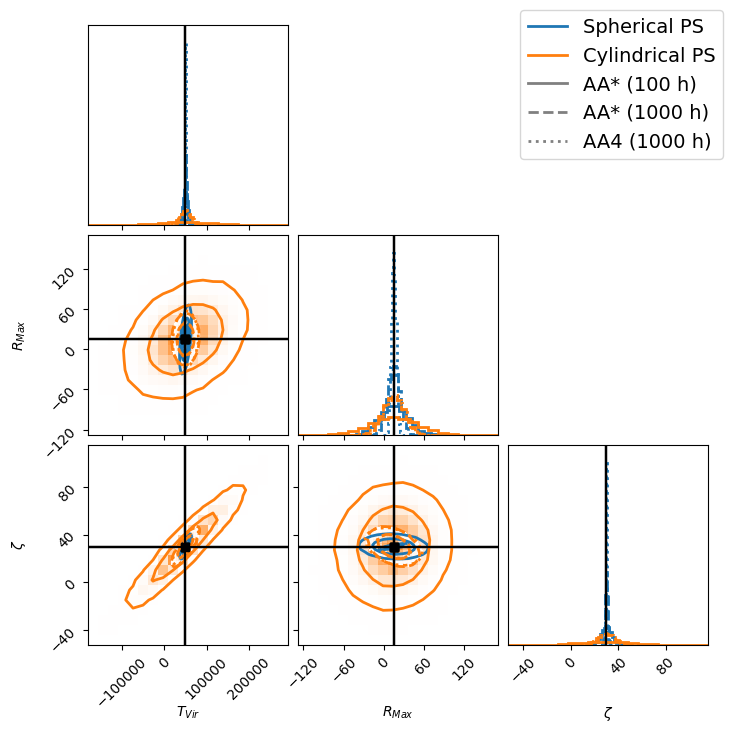

In [ ]:
# --- Plotting ---
n_samples = 100000
fig = None

# Loop through both 'PS 1D' and 'PS 2D' models
for model_type, cases in model_files.items():
    color = style_guide[model_type]['color']
    # Loop through the different observation cases
    for case_name, file_path in cases.items():
        linestyle = linestyles[case_name][0]
        
        # Load covariance and generate samples
        cov = np.loadtxt(file_path)
        fisher_samples = np.random.multivariate_normal(fid, cov, size=n_samples)
        
        # Add samples to the corner plot with specified styles
        fig = corner.corner(
            fisher_samples,
            fig=fig,
            labels=Fisher_Param,
            plot_datapoints=False,
            levels=(0.68, 0.95),
            truths=fid,
            truth_color='black',
            color=color, # Base color for the group
            # Apply linestyles to both 1D histograms and 2D contours
            hist_kwargs={'linestyle': linestyle, 'lw': 2, 'density': True},
            contour_kwargs={'linestyles': linestyle, 'linewidths': 2},
            range=[],
        )

# --- Create Custom Legend ---
# Create proxy artists for the legend
legend_elements = []

# Add entries for model types (colors)
for model_type, styles in style_guide.items():
    legend_elements.append(mlines.Line2D(
        [], [], color=styles['color'], lw=2, label=styles['label']
    ))
    
# Add entries for observation cases (linestyles)
for case_name, (ls, label) in linestyles.items():
     legend_elements.append(mlines.Line2D(
        [], [], color='gray', lw=2, linestyle=ls, label=label
    ))

# Add the legend to the top-right corner of the figure
fig.legend(handles=legend_elements, loc='upper right', fontsize=14, bbox_to_anchor=(0.98, 0.98))

plt.show()